# EO-SAR Binary Change Detection - Data Exploration

Run the cells below to install dependencies and analyze the dataset.

In [4]:
# Install required libraries
%pip install tifffile rasterio numpy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from pathlib import Path
import pandas as pd

dataset_root = Path('../dataset')
splits = ['train', 'val', 'test']

## 1. Dataset Statistics

In [6]:
stats = []
for split in splits:
    split_path = dataset_root / split
    if not split_path.exists(): continue
    
    pre = list((split_path / 'pre-event').glob('*.tif'))
    post = list((split_path / 'post-event').glob('*.tif'))
    target = list((split_path / 'target').glob('*.tif'))
    
    stats.append({
        'Split': split,
        'Pre-Event (EO/SAR)': len(pre),
        'Post-Event (EO/SAR)': len(post),
        'Target (Mask)': len(target)
    })

print(pd.DataFrame(stats))

   Split  Pre-Event (EO/SAR)  Post-Event (EO/SAR)  Target (Mask)
0  train                2781                 2781           2781
1    val                 334                  334            334
2   test                  77                   77             77


## 2. Visualize Samples

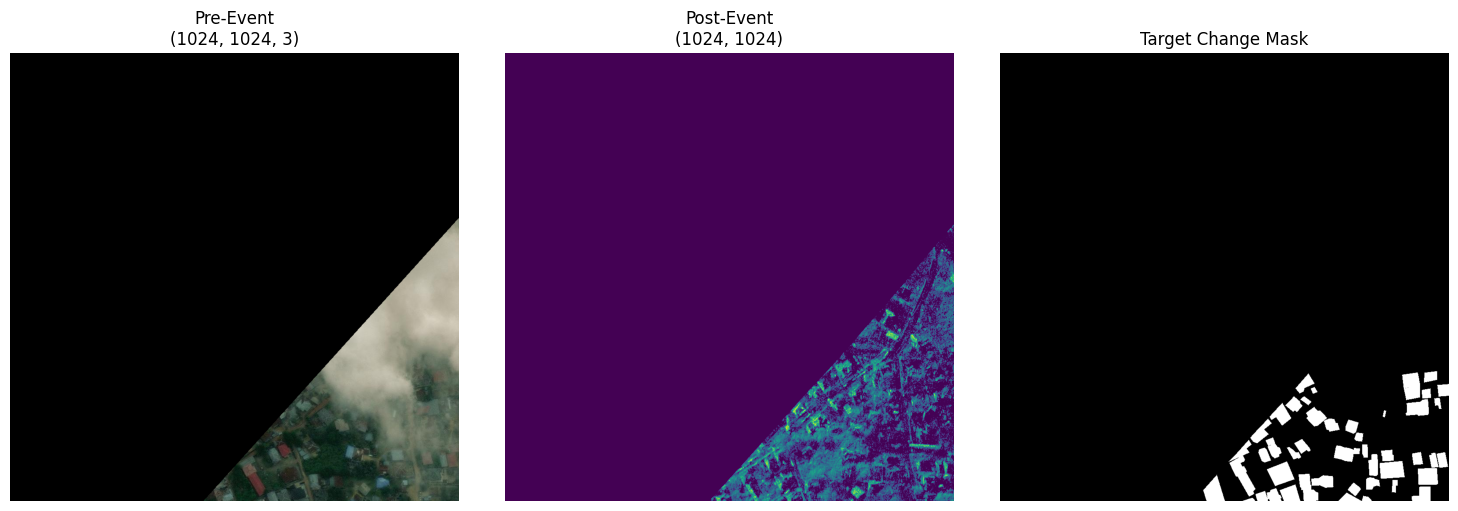

In [5]:
def plot_triplet(split='train', index=0):
    split_path = dataset_root / split
    fnames = sorted([f.name for f in (split_path / 'pre-event').glob('*.tif')])
    
    pre_img = tiff.imread(split_path / 'pre-event' / fnames[index])
    post_img = tiff.imread(split_path / 'post-event' / fnames[index])
    
    target_path = split_path / 'target' / fnames[index]
    target_img = tiff.imread(target_path) if target_path.exists() else None
    
    cols = 3 if target_img is not None else 2
    fig, axes = plt.subplots(1, cols, figsize=(15, 5))
    
    axes[0].imshow(pre_img)
    axes[0].set_title(f'Pre-Event\n{pre_img.shape}')
    
    axes[1].imshow(post_img)
    axes[1].set_title(f'Post-Event\n{post_img.shape}')
    
    if target_img is not None:
        axes[2].imshow(target_img, cmap='gray')
        axes[2].set_title('Target Change Mask')
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the first triplet
plot_triplet(index=0)